# Part 1: Penguin

In this part of the assignment you will analyze a dataset of measurements about three different species of Penguins. 

**Learning objectives.** You will:
1. Train and test a linear model using ordinary least squares regression. 
2. Use numerical Python (NumPy) and the standard `sklearn` API in Python  
2. Use a One-Hot-Encoding to incorporate categorical features as inputs to a linear predictive model.
3. Inspect model coefficients and scatterplot visualizations to interpret a change in model coefficients for two different linear models.
4. Distinguish between correlation and causation in machine learning.

We begin by importing the dataset and providing a visualization of how the numerical features vary by species. The dataset and visualizations come from the [`seaborn`](https://seaborn.pydata.org/) library -- a higher level visualization library for scientific Python built on top of the core [`matplotlib`](https://matplotlib.org/). If you do not already have `seaborn` installed, you can do so below.

The data are returned as a `pandas` `dataframe`. [`pandas`](https://pandas.pydata.org/docs/user_guide/10min.html) is a popular library for data science in Python. A `dataframe` is a data table that can be indexed by column names as shown in the code below. You can always convert a `dataframe` to a NumPy array by simply calling `.values` or [`.to_numpy`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_numpy.html#pandas.DataFrame.to_numpy).

In [1]:
# Run the following to install the seaborn package
# if your environment does not already have seaborn
# installed.

!pip install seaborn


Defaulting to user installation because normal site-packages is not writeable


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


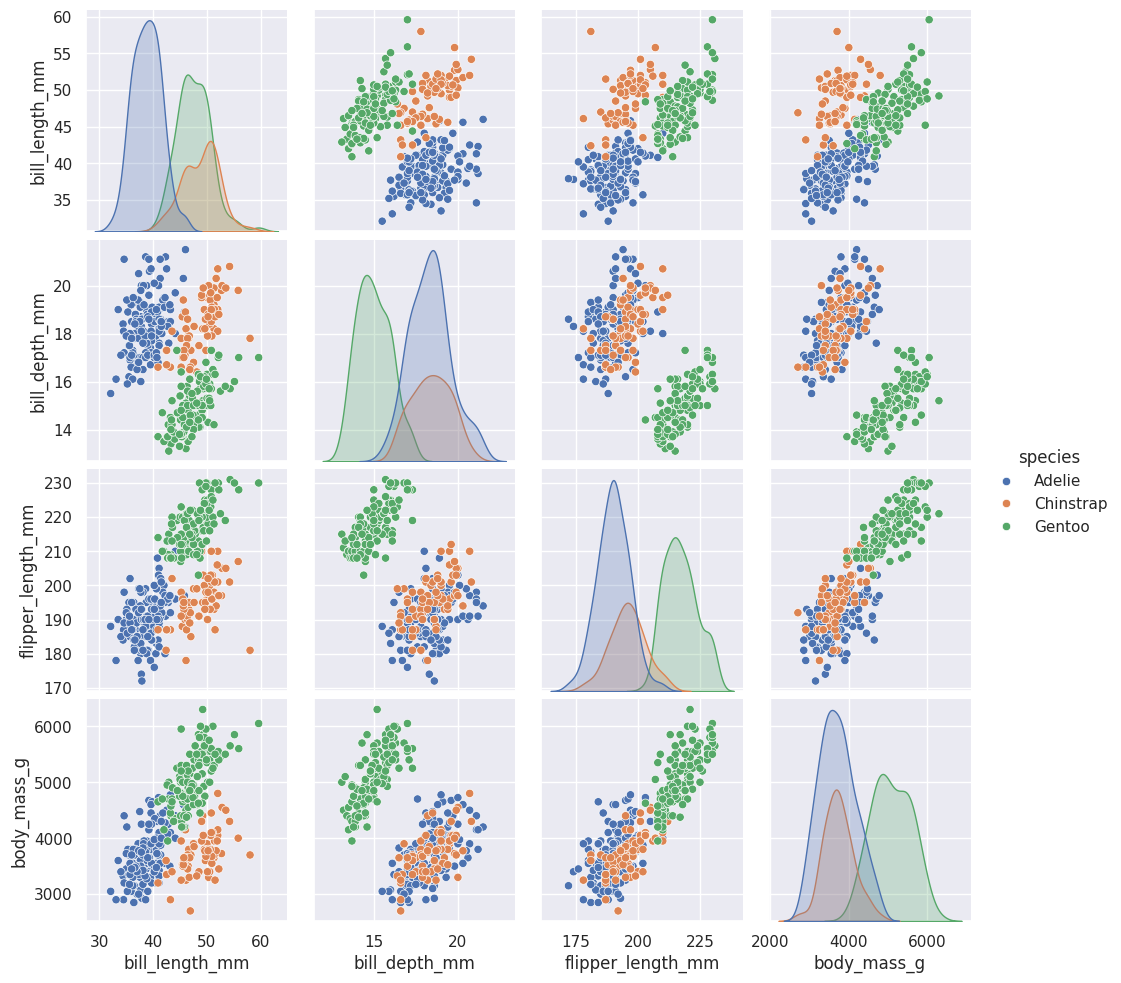

In [2]:
# Run but do not modify this code

import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme()

# Only 11 penguins out of over 300 are missing any data;
# we simply drop those here
penguins = sns.load_dataset("penguins").dropna()
sns.pairplot(data=penguins, hue="species")
penguins.head()

## Task 1

We will build predictive models using `bill_length_mm`, `bill_depth_mm`, `species`, and `sex` as our inputs (or features) and attempting to predict `flipper_length_mm` as the output (or target). The code below gets the appropriate columns of data and converts them to NumPy arrays for you, inputs as `X` and predictive targets as `y`.

Use `sklearn` to randomly split the input data into a [train and test partition](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html), with 30% of the data reserved for testing. Use a random seed of `2025` for reproducibility of the results.

Print the number of data points in the resulting train and test partitions.

In [3]:
X = penguins[["bill_length_mm", "bill_depth_mm", "species", "sex"]].values
y = penguins["flipper_length_mm"].values

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2025)

print("Number of training points = ", len(X_train))
print("Number of test points = ", len(X_test))

# Finish code for task 1 code here

Number of training points =  233
Number of test points =  100


## Task 2

Run the following cell to visualize the relationship between `bill_length_mm`, `bill_depth_mm` and `flipper_length_mm`. You should observe (perhaps unsurprisingly) that penguins with larger bills tend to have longer flippers.

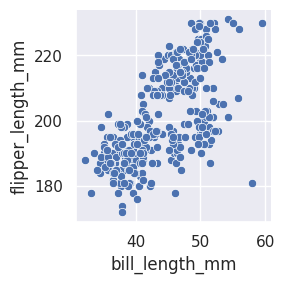

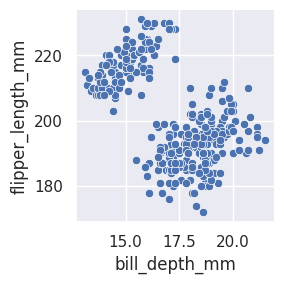

In [4]:
# Run but do not modify this code
sns.relplot(data=penguins, x="bill_length_mm", y="flipper_length_mm", height=3)
sns.relplot(data=penguins, x="bill_depth_mm", y="flipper_length_mm", height=3)

Fit a linear predictive model using [ordinary least squares regression](https://scikit-learn.org/stable/modules/linear_model.html#ordinary-least-squares) on the training data to predict `flipper_length_mm` as a function of `bill_length_mm` and `bill_depth_mm` only (do not use `species` or `sex` for this task).

Use the model to make predictions on the test data (again, without using `species` or `sex` for this task), and evaluate the [root mean squared error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_error.html#sklearn.metrics.root_mean_squared_error) of the predictions on **both** the training data **and** the test data (that is, the training error and the generalization error). Report both.

----

**Hint:** Array slicing reminders: Since `X_train` and `X_test` are 2D numpy arrays with shape `(n_samples, n_features)`, you can extract specific columns using slicing notation:
- `array[:, 0]` gets the first column (all rows, column 0)
- `array[:, :2]` gets the first two columns (all rows, columns 0 and 1) 
- `array[:, 2:]` gets columns from index 2 onward (all rows, columns 2, 3, etc.)
- `array[:, [0, 2]]` gets specific non-contiguous columns (columns 0 and 2)

The colon `:` means "all rows" and the part after the comma specifies which columns. See the [numpy indexing documentation](https://numpy.org/doc/stable/user/basics.indexing.html) for more details. Remember that in this dataset, the features are ordered as: `bill_length_mm`, `bill_depth_mm`, `species`, `sex`.

In [5]:
# Write code for task 2 here
from sklearn import linear_model

reg = linear_model.LinearRegression()
reg.fit(X_train[:,:2],y_train)

from sklearn.metrics import root_mean_squared_error

#predict on training data
y_train_predict = reg.predict(X_train[:,:2])
rmse_train = root_mean_squared_error(y_train_predict, y_train)
print("Root mean squared error on training data = ", rmse_train)
#predict on test data
y_test_predict = reg.predict(X_test[:,:2])
rmse_test = root_mean_squared_error(y_test_predict, y_test)
print("Root mean squared error on test data = ", rmse_test)

Root mean squared error on training data =  8.904827088796983
Root mean squared error on test data =  7.951792432428022


## Task 3

One way to improve the performance of our model is to include the `species` and `sex` features. That is, we now want to predict `flipper_length_mm` as a function of `bill_length_mm`, `bill_depth_mm`, `species`, and `sex`. However, the `species` and `sex` features are both categorical, not numerical. The following steps guide you through combining these features and training a model.

1. **Extract features by type**: Separate your training and test data into numerical features (`bill_length_mm`, `bill_depth_mm`) and categorical features (`species`, `sex`).

2. **One-hot encode categorical features**: Use [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) to convert the categorical data. Fit the encoder only once on the training data, then use it to transform both training and test data.

3. **Combine feature arrays**: You'll need to combine your numerical features with the one-hot encoded categorical features into single feature matrices for training and testing. Consider using [numpy.column_stack](https://numpy.org/doc/stable/reference/generated/numpy.column_stack.html) or [numpy.hstack](https://numpy.org/doc/stable/reference/generated/numpy.hstack.html) to combine 2D arrays.

4. **Fit and evaluate**: Use the combined feature matrices to fit a linear regression model and evaluate its performance using [root mean squared error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_error.html) on **both** the training data **and** the test data (that is, the training error and the generalization error). Report both.

You should have observed that incorporating the `species` and `sex` features improved the quality of our predictions for `flipper_length_mm`. 

**Hint**: Check the `.shape` of your arrays at each step to ensure they're compatible for combining and model fitting.

In [6]:
# Write code for task 3 here
# Split into numerical and categorical features
numerical_features = X[:,:2]
categorical_data = X[:,2:]

from sklearn.preprocessing import OneHotEncoder
# Encode categorical features
encoder = OneHotEncoder(sparse_output=False)  # use sparse=False if you're on an older sklearn version
transformed = encoder.fit_transform(categorical_data)
X_encoded = np.hstack((numerical_features, transformed))
X_encoded_train, X_encoded_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=2025)

# Train model with categorical features
from sklearn import linear_model

reg_with_encoded = linear_model.LinearRegression()
reg_with_encoded.fit(X_encoded_train, y_train)


#predict on training data
y_train_predict = reg_with_encoded.predict(X_encoded_train)
rmse_train = root_mean_squared_error(y_train_predict, y_train)
print("Root mean squared error on training data = ", rmse_train)
#predict on test data
y_test_predict = reg_with_encoded.predict(X_encoded_test)
rmse_test = root_mean_squared_error(y_test_predict, y_test)
print("Root mean squared error on test data = ", rmse_test)

Root mean squared error on training data =  5.577596604303367
Root mean squared error on test data =  5.04002827408178


## Task 4

Examine the model coefficients for the original model (not incorporating `species` or `sex`) from task 2 versus the model coefficients from the combined model in task 3. You should observe that:
  - the task 2 model has a negative coefficient for `bill_depth_mm` (meaning the model predicts penguins with deeper bills will have shorter flippers), 
  - but the task 3 model has a positive coefficient for `bill_depth_mm` (meaning the model predicts penguins with deeper bills will have longer flippers).

  You can look at the coefficients by printing the `.coef_` attributes of the [Linear Regression](https://scikit-learn.org/stable/modules/linear_model.html#ordinary-least-squares) models you created.

In [7]:
# Write code for task 4 here
print(reg.coef_)

print(reg_with_encoded.coef_)

[ 1.36160104 -3.17413995]
[  0.37864447   1.37956554 -10.02377848  -8.31315201  18.33693049
  -1.70801734   1.70801734]


How can we explain this strange reversal? Run the code below to generate three visualizations. Referring to the visualizations to justify your answer: 
 - Explain why the model coefficient for `bill_depth_mm` changed from being negative in task 2 to positive in task 3. 
 - Referencing this example, explain why a correlation between an input and target variable in a linear regression model does NOT prove that the input **causes** the output. (Optional: You may find the discussion of [Simpson's Paradox](https://en.wikipedia.org/wiki/Simpson%27s_paradox) to be informative.)

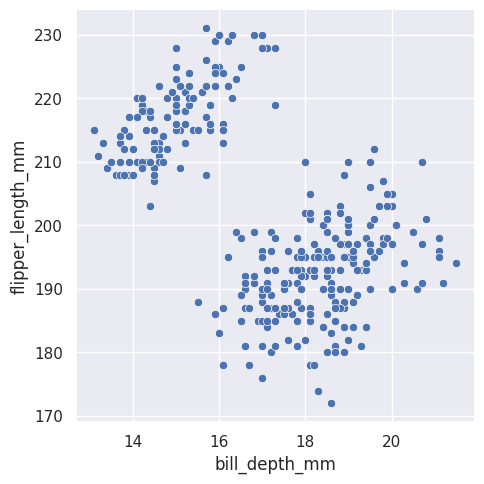

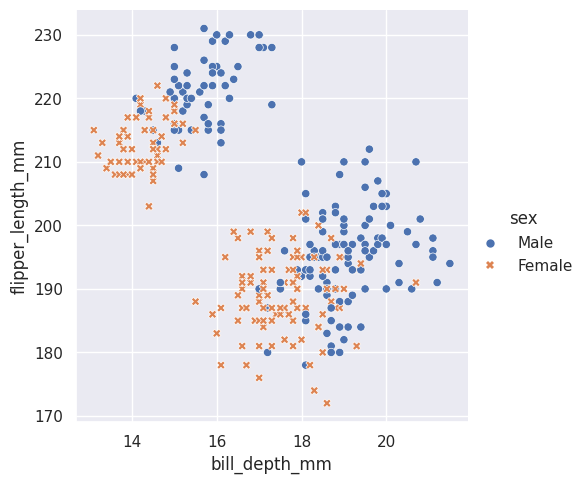

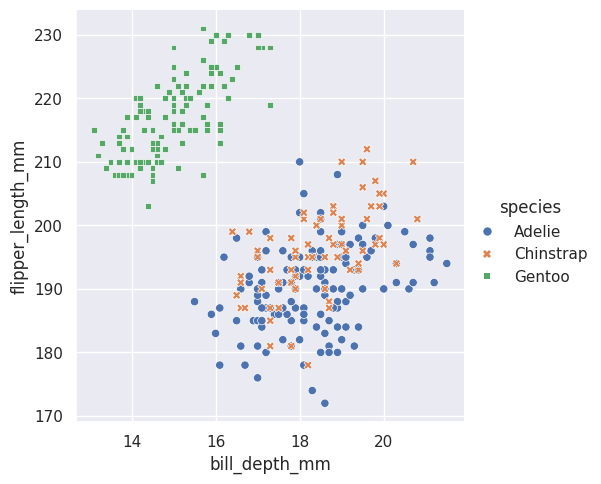

In [8]:
# Run but do not modify this code

sns.relplot(data=penguins, x="bill_depth_mm", y="flipper_length_mm")
sns.relplot(data=penguins, x="bill_depth_mm", y="flipper_length_mm", hue="sex", style="sex")
sns.relplot(data=penguins, x="bill_depth_mm", y="flipper_length_mm", hue="species", style="species")

One explanation is that the data is in two clusters (as can be seen in the first visualization), each with a positive correlation between bill depth and flipper length. However, the two clusters are centered with a negative correlation between bill depth and flipper length. In the original model, there is no other data to distinguish the two clusters, so the coefficient comes out negative, as the model needs to find the trend between the clusters. In the second model accounting for categorical data, the model can distinguish between the clusters. In the third visualization, it is clear that one cluster is the Gentoo penguins, while the other is Adelie and Chinstrap. The second model is able to account for the species, so it can distinguish between the clusters. Thus, it is able to more accurately find the positive correlation within a cluster, getting the positive coefficient.

It is not entirely accurate to get the positive coefficient. As the second visualization shows, each of the clusters are really made of two clusters, one of male penguins and one of female. The sexes are very separate in the graph, making it seem like sex is the greater determiner of flipper length than bill depth, as within one particular sex of one of the species clusters, there is little to no correlation between bill depth and flipper length. Thus, it seems that bill depth and flipper length are correlated as traits of a penguins species and sex rather than having a causal relationship. This is one example of how correlation does not equal causation. Often times finding that two variables are correlated is a sign that there is some other trait that causes both of them.